In [12]:
import warnings
warnings.filterwarnings("ignore")
import logging
# Suppress INFO logs, show only WARNING and above
logging.getLogger().setLevel(logging.WARNING)


from repspat import SampleData, spatial_silhouette_analysis,spatial_constrained_hac, plot_spatial_clusters, pairwise_results_to_matrix, multiple_comparison, create_blocks


In [ ]:
import scanpy as sc

adata = sc.read("brain_data.h5ad")

In [3]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

class SpatialDataContainer:
    def __init__(self, adata, to_dense=False):
        # --- store raw AnnData ---
        self.sample_adata = adata

        # --- Feature matrix ---
        X = adata.X.toarray() if to_dense and hasattr(adata.X, "toarray") else adata.X

        self.feature_mat = pd.DataFrame(
            X,
            columns=adata.var_names,
            index=adata.obs_names
        )

        # --- Coordinates matrix ---
        self.coords_mat = pd.DataFrame(
            adata.obsm["spatial"],
            columns=["centroidX", "centroidY"],
            index=adata.obs_names
        )

        # --- Distance matrix (WARNING: O(n²) memory heavy) ---
        dist = squareform(pdist(self.feature_mat, metric="euclidean"))

        self.dist_matrix = pd.DataFrame(
            dist,
            index=self.feature_mat.index,
            columns=self.feature_mat.index
        )

In [4]:
data = SpatialDataContainer(adata)

data.feature_mat
data.coords_mat
data.dist_matrix
data.sample_adata

AnnData object with n_obs × n_vars = 48556 × 960
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI'
    obsm: 'spatial'

In [5]:
spatial_silhouette_analysis(data, n_neighbors_list=[8], n_clusters_range=range(8,19))

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


,n_neighbors,n_clusters,avg_silhouette
0,8,8,0.050285
1,8,9,0.052172
2,8,10,0.050548
3,8,11,0.053673
4,8,12,0.056325
5,8,13,0.056979
6,8,14,0.056218
7,8,15,0.056128
8,8,16,0.057199
9,8,17,0.059001


In [6]:
labels, feature_df, model = spatial_constrained_hac(data.sample_adata, feature_df=data.feature_mat, n_clusters=44, n_neighs=6)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


In [7]:
x = data.coords_mat.centroidX
y = data.coords_mat.centroidY

(<Figure size 800x1000 with 1 Axes>,
 <Axes: title={'center': 'Spatial Plot of Cells with Cluster Colors'}, xlabel='X coordinate', ylabel='Y coordinate'>)

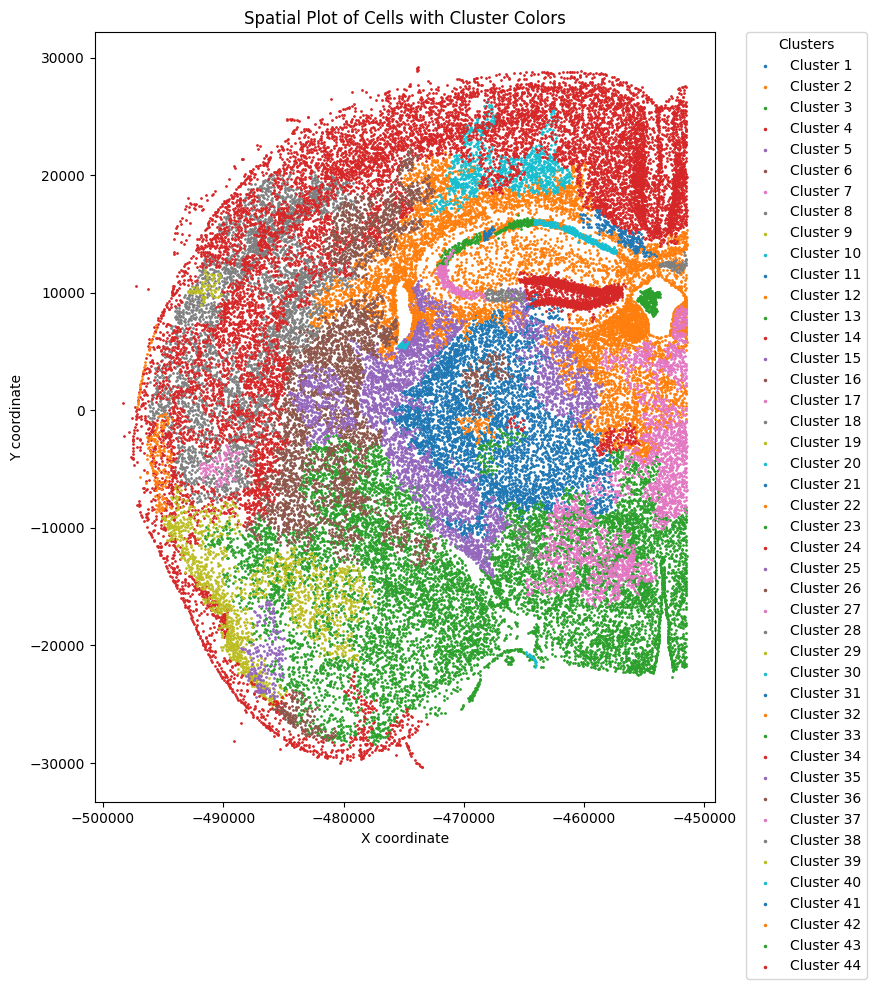

In [8]:
plot_spatial_clusters(x,y,labels=labels,point_size=1,alpha=1,figsize=(8, 10) )

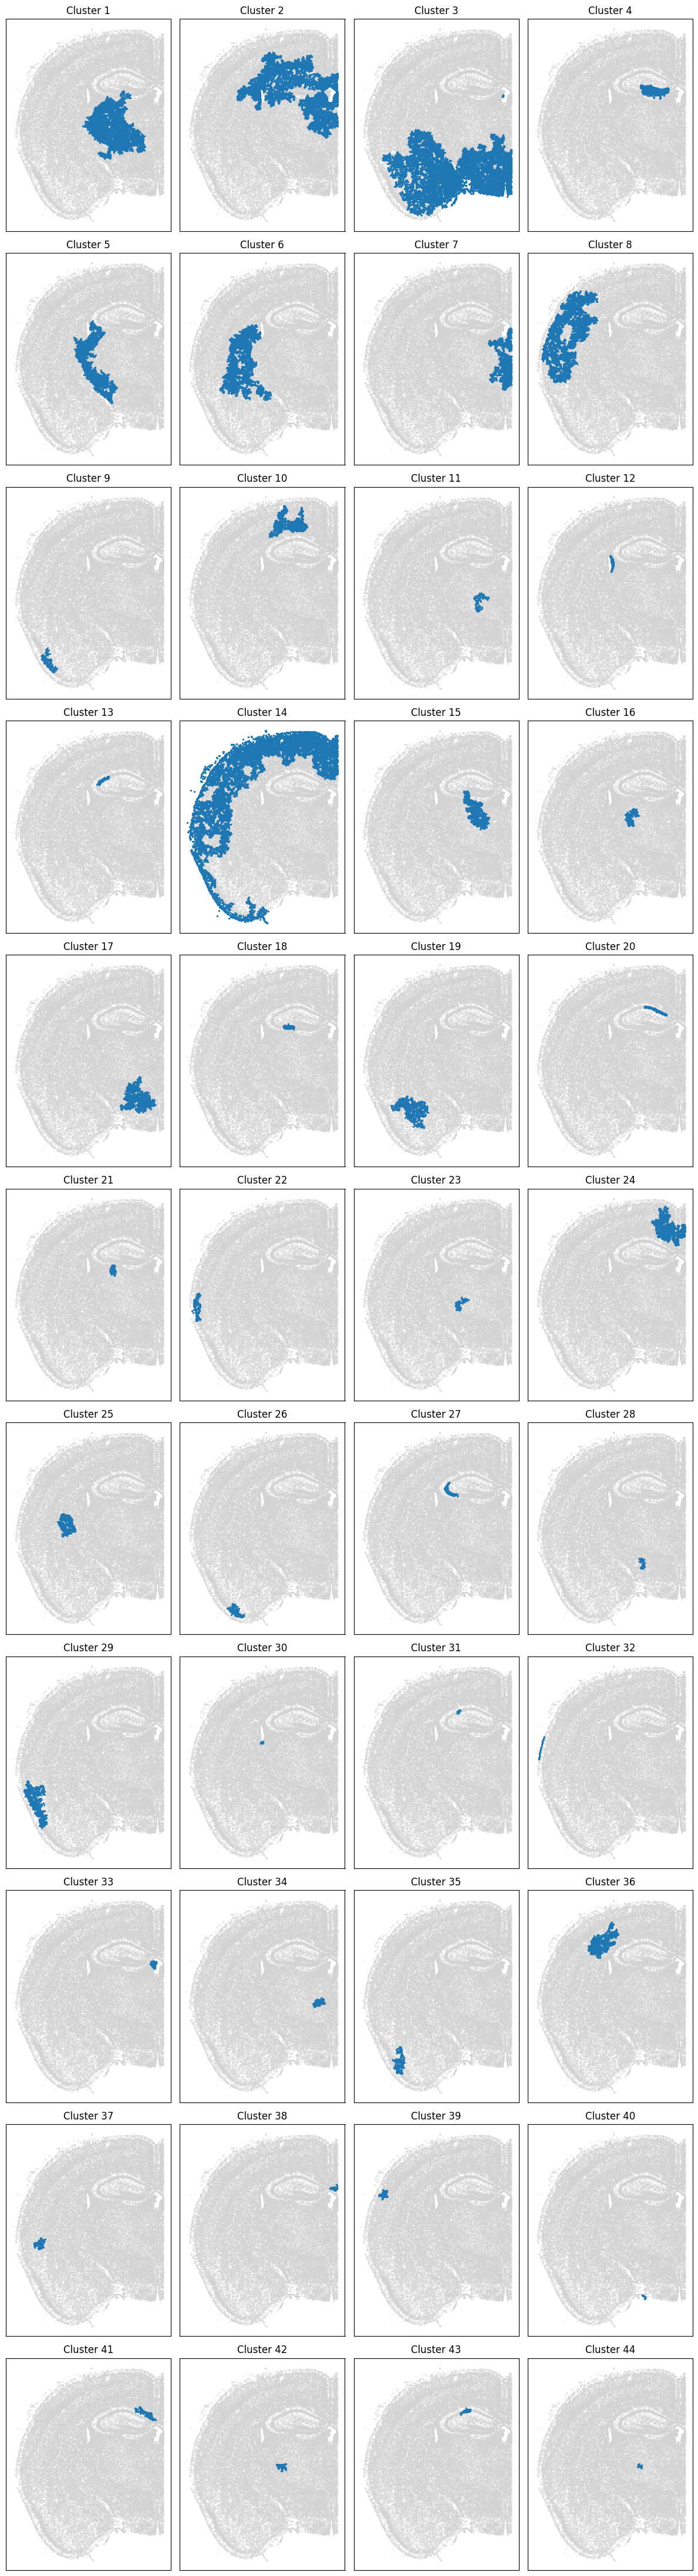

In [9]:
import matplotlib.pyplot as plt
import numpy as np

clusters = np.unique(labels)

ncols = 4
nrows = int(np.ceil(len(clusters) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3*ncols, 4*nrows)
)

axes = axes.flatten()

for ax, cluster in zip(axes, clusters):
    mask = labels == cluster

    # background
    ax.scatter(
        x[~mask],
        y[~mask],
        c="lightgray",
        s=1,
        alpha=0.3
    )

    # cluster of interest
    ax.scatter(
        x[mask],
        y[mask],
        s=2
    )

    ax.set_title(f"Cluster {cluster}")
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(clusters):]:
    ax.axis("off")

plt.tight_layout()
plt.show()